# GTEx tissue feature importance analysis (True-label binary + SHAP): B matrix

1. Load GTEx LV data (B matrix) and tissue metadata
2. Use true GTEx SMTSD tissue labels directly (no clustering)
3. Load per-tissue binary RF + SHAP results
4. Annotate each LV with its dominant tissue from the top 1% of B-matrix samples
5. Downstream: tissue specificity heatmap (individual and grouped)

💡 **Environment:** `clamp-analyses`

## Libraries

In [1]:
import os
import pickle
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

from pyprojroot.here import here
import shap

import rpy2.robjects as ro
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import pandas2ri
readRDS = ro.r["readRDS"]

import csv
import re
import textwrap
import urllib.request
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
from itertools import groupby

np.random.seed(42)

/home/msubirana/miniconda3/envs/clamp-analyses/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Settings

# Output

In [2]:
OUTPUT_DIR = here('output/03_model_biology/01_gtex/01_LV_importance_rf_true_labels/gtex_feature_importance_true_labels_binary_shap')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {OUTPUT_DIR}")

Output directory: /home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/01_gtex/01_LV_importance_rf_true_labels/gtex_feature_importance_true_labels_binary_shap


# Load data

In [3]:
# load .rds files from CLAMP with different priors
gtex_CLAMPfull_rds = readRDS(str(here('output/01_model_building/01_gtex/CLAMPfull.rds')))


def extract_B_matrix(rds_obj):
    B_matrix = rds_obj.rx2("B")
    with localconverter(ro.default_converter + pandas2ri.converter):
        B_values = ro.conversion.rpy2py(B_matrix)
    df = pd.DataFrame(
        data=B_values,
        index=B_matrix.rownames if B_matrix.rownames else None,
        columns=B_matrix.colnames if B_matrix.colnames else None,
    )
    return df

gtex_CLAMPfull = extract_B_matrix(gtex_CLAMPfull_rds)

lv_data = gtex_CLAMPfull
lv_data.head()

,GTEX-1117F-0226-SM-5GZZ7,GTEX-1117F-0426-SM-5EGHI,GTEX-1117F-0526-SM-5EGHJ,GTEX-1117F-0626-SM-5N9CS,GTEX-1117F-0726-SM-5GIEN,GTEX-1117F-1326-SM-5EGHH,GTEX-1117F-2426-SM-5EGGH,GTEX-1117F-2526-SM-5GZY6,GTEX-1117F-2826-SM-5GZXL,GTEX-1117F-2926-SM-5GZYI,...,GTEX-ZZPU-1126-SM-5N9CW,GTEX-ZZPU-1226-SM-5N9CK,GTEX-ZZPU-1326-SM-5GZWS,GTEX-ZZPU-1426-SM-5GZZ6,GTEX-ZZPU-1826-SM-5E43L,GTEX-ZZPU-2126-SM-5EGIU,GTEX-ZZPU-2226-SM-5EGIV,GTEX-ZZPU-2426-SM-5E44I,GTEX-ZZPU-2626-SM-5E45Y,GTEX-ZZPU-2726-SM-5NQ8O
LV1,0.038220,-0.035718,0.058029,0.046667,0.014035,-0.002800,0.036971,0.029603,0.075848,0.070109,...,-0.074388,0.060693,0.008793,0.000346,-0.064704,0.015187,0.001466,-0.066104,-0.145394,0.006629
LV2,-0.172913,-0.142436,-0.177395,-0.129254,-0.142321,-0.174625,-0.172582,-0.079782,-0.184006,-0.092761,...,-0.140227,-0.095136,-0.129896,-0.109970,-0.114404,-0.178207,-0.090775,-0.173437,-0.175773,-0.177160
LV3,-0.052967,-0.119714,0.045306,-0.177612,-0.004371,-0.013131,0.071965,-0.072757,-0.003389,0.054140,...,0.031745,1.396569,-0.218557,0.123030,-0.091181,0.613276,0.111563,0.140791,-0.073572,-0.006682
LV4,0.684940,0.194151,0.258987,0.042777,0.297042,0.270592,0.071725,-0.321013,0.272885,0.105102,...,0.162523,-0.028583,0.097821,0.032877,-0.020901,-0.004998,-0.422042,-0.002357,-0.126704,0.265592
LV5,0.238198,0.206424,0.082470,0.006714,0.030963,0.042211,-0.158377,-0.226136,0.080164,-0.183551,...,0.009347,-0.006413,-0.007506,0.160013,-0.028191,-0.011097,-0.354041,-0.074878,0.058859,0.121228


In [4]:
def extract_summary_matrix(rds_obj):
    summary_matrix = rds_obj.rx2("summary")
    with localconverter(ro.default_converter + pandas2ri.converter):
        summary_values = ro.conversion.rpy2py(summary_matrix)
    df = pd.DataFrame(
        data=summary_values,
        index=summary_matrix.rownames if summary_matrix.rownames else None,
        columns=summary_matrix.colnames if summary_matrix.colnames else None,
    )
    return df

gtex_CLAMPfull_summary = extract_summary_matrix(gtex_CLAMPfull_rds)
gtex_CLAMPfull_summary["pathway"] = gtex_CLAMPfull_summary["pathway"].str.replace("C2CP_", "", regex=False)

print(gtex_CLAMPfull_summary.shape)
gtex_CLAMPfull_summary.head()

(4160, 7)


,pathway,LV,AUC,p_value,FDR,npos,nneg
BP529,BP_Calcium-Independent Cell-Cell Adhesion via ...,LV1,0.606766,0.289486,0.700379,2,21512
BP878,BP_Defense Response to Symbiont (GO:0140546),LV1,0.240866,0.911012,0.948822,2,21512
BP1258,BP_Glycolipid Catabolic Process (GO:0019377),LV1,0.240866,0.911012,0.948822,2,21512
BP2301,BP_Negative Regulation of Programmed Necrotic ...,LV1,0.529042,0.440030,0.780830,2,21512
BP3194,BP_Positive Regulation of Macrophage Different...,LV1,0.722759,0.123478,0.459043,2,21512


In [5]:
path = here('data/gtex/GTEx_Analysis_v8_Annotations_SampleAttributesDS.txt')

gtex_meta = pd.read_csv(
    path,
    sep='\t',
    header=0,
    dtype=str,
    quoting=csv.QUOTE_NONE,
    engine='python',
    comment=None,
    keep_default_na=False,
    on_bad_lines='warn'
)

print(gtex_meta.shape)
gtex_meta.head()

(22951, 63)


,SAMPID,SMATSSCR,SMCENTER,SMPTHNTS,SMRIN,SMTS,SMTSD,SMUBRID,SMTSISCH,SMTSPAX,...,SME1ANTI,SMSPLTRD,SMBSMMRT,SME1SNSE,SME1PCTS,SMRRNART,SME1MPRT,SMNUM5CD,SMDPMPRT,SME2PCTS
0,GTEX-1117F-0003-SM-58Q7G,,B1,,,Blood,Whole Blood,0013756,1188,,...,,,,,,,,,,
1,GTEX-1117F-0003-SM-5DWSB,,B1,,,Blood,Whole Blood,0013756,1188,,...,,,,,,,,,,
2,GTEX-1117F-0003-SM-6WBT7,,B1,,,Blood,Whole Blood,0013756,1188,,...,,,,,,,,,,
3,GTEX-1117F-0011-R10a-SM-AHZ7F,,"B1, A1",,,Brain,Brain - Frontal Cortex (BA9),0009834,1193,,...,,,,,,,,,,
4,GTEX-1117F-0011-R10b-SM-CYKQ8,,"B1, A1",,7.2,Brain,Brain - Frontal Cortex (BA9),0009834,1193,,...,,,,,,,,,,


In [ ]:
# transpose to get samples as rows, LVs as columns
lv_matrix = lv_data.T

# filter metadata to only include samples in LV matrix
meta_filtered = gtex_meta[gtex_meta['SAMPID'].isin(lv_matrix.index)].copy()
meta_filtered = meta_filtered.set_index('SAMPID')
meta_filtered = meta_filtered.loc[lv_matrix.index]

tissue_labels = meta_filtered['SMTSD']

print(f"Number of samples: {len(lv_matrix)}")
print(f"Number of LVs: {lv_matrix.shape[1]}")
print(f"Number of unique tissues: {tissue_labels.nunique()}")
print(f"\nTissue distribution:")
print(tissue_labels.value_counts().head())

# True tissue labels

Use the true GTEx SMTSD labels directly as tissue labels for each RF (no clustering step).

In [ ]:
# Use true GTEx SMTSD labels directly for downstream SHAP biology summaries.
true_tissue_labels = tissue_labels.copy()
print("GTEx true tissue label distribution:")
print(true_tissue_labels.value_counts())


In [9]:
accuracy_df = pd.read_csv(OUTPUT_DIR / "accuracy_summary.tsv", sep="\t")
shap_results_df = pd.read_csv(OUTPUT_DIR / "all_shap_positive.tsv", sep="\t")
cumulative_df = pd.read_csv(OUTPUT_DIR / "cumulative_importance.tsv", sep="\t")

In [10]:
MIN_RF_ACCURACY = 0.9

# LV tissue annotation

For each LV, take the top 1% of samples (highest B matrix values) and annotate the LV with the dominant tissue.
Then build a heatmap showing how tissue-specific the top SHAP LVs are.

In [11]:
# annotate each LV using the top 1% of samples from the B matrix
n_top = max(1, int(len(lv_matrix) * 0.01))

lv_tissue_pct = {}
lv_tissue_annotation = {}

for lv in lv_matrix.columns:
    top_idx = lv_matrix[lv].nlargest(n_top).index
    top_tissues = tissue_labels.loc[top_idx]
    pct_dist = (top_tissues.value_counts(normalize=True) * 100).to_dict()
    lv_tissue_pct[lv] = pct_dist
    lv_tissue_annotation[lv] = top_tissues.value_counts().index[0]

lv_annot_df = pd.DataFrame({
    'LV': list(lv_tissue_annotation.keys()),
    'Annotated_Tissue': list(lv_tissue_annotation.values()),
}).set_index('LV')

print(f"top 1% = {n_top} samples per LV")
print(f"\nLV annotations per tissue:")
print(lv_annot_df['Annotated_Tissue'].value_counts())
lv_annot_df.head(10)

top 1% = 173 samples per LV

LV annotations per tissue:
Annotated_Tissue
Whole Blood                                  53
Cells - Cultured fibroblasts                 42
Nerve - Tibial                               29
Thyroid                                      29
Lung                                         28
Cells - EBV-transformed lymphocytes          26
Artery - Tibial                              24
Brain - Cerebellar Hemisphere                20
Muscle - Skeletal                            19
Ovary                                        19
Skin - Not Sun Exposed (Suprapubic)          18
Skin - Sun Exposed (Lower leg)               16
Adipose - Subcutaneous                       15
Adipose - Visceral (Omentum)                 15
Pituitary                                    15
Esophagus - Mucosa                           14
Testis                                       14
Brain - Cerebellum                           13
Liver                                        13
Artery - Aorta 

,Annotated_Tissue
LV,
LV1,Pancreas
LV2,Brain - Frontal Cortex (BA9)
LV3,Adrenal Gland
LV4,Whole Blood
LV5,Nerve - Tibial
LV6,Cells - Cultured fibroblasts
LV7,Muscle - Skeletal
LV8,Whole Blood
LV9,Heart - Left Ventricle


In [12]:
CUMULATIVE_PCT = 25

valid_tissues = accuracy_df[
    accuracy_df['Best_Test_Balanced_Accuracy'] >= MIN_RF_ACCURACY
]['Tissue'].tolist()

tissues_ordered = sorted(valid_tissues)

results = []
for tissue in tissues_ordered:
    df_t = cumulative_df[cumulative_df['Tissue'] == tissue].sort_values('Rank')
    mask = df_t['Cumulative_Percent'] >= CUMULATIVE_PCT
    n = int(df_t.loc[mask, 'Rank'].iloc[0]) if mask.any() else len(df_t)
    cum_at_n = df_t[df_t['Rank'] == n]['Cumulative_Percent'].values[0]
    results.append({'Tissue': tissue, 'N_lvs': n, 'CumPct': round(cum_at_n, 1)})

results_df = pd.DataFrame(results)
display(results_df)

n_per_tissue = results_df.set_index('Tissue')['N_lvs'].to_dict()
top_per_tissue = {
    tissue: shap_results_df[shap_results_df['Tissue'] == tissue]['Feature']
                .head(n_per_tissue[tissue]).tolist()
    for tissue in n_per_tissue
}

for tissue, n in sorted(n_per_tissue.items()):
    print(f"  {tissue}: {n} LVs")

,Tissue,N_lvs,CumPct
0,Adipose - Subcutaneous,6,27.5
1,Adipose - Visceral (Omentum),5,25.3
2,Adrenal Gland,2,27.5
3,Artery - Aorta,3,31.1
4,Artery - Coronary,4,29.9
5,Artery - Tibial,4,28.0
6,Brain - Amygdala,4,26.5
7,Brain - Anterior cingulate cortex (BA24),6,25.3
8,Brain - Caudate (basal ganglia),8,27.3
9,Brain - Cerebellar Hemisphere,9,26.6


  Adipose - Subcutaneous: 6 LVs
  Adipose - Visceral (Omentum): 5 LVs
  Adrenal Gland: 2 LVs
  Artery - Aorta: 3 LVs
  Artery - Coronary: 4 LVs
  Artery - Tibial: 4 LVs
  Brain - Amygdala: 4 LVs
  Brain - Anterior cingulate cortex (BA24): 6 LVs
  Brain - Caudate (basal ganglia): 8 LVs
  Brain - Cerebellar Hemisphere: 9 LVs
  Brain - Cerebellum: 8 LVs
  Brain - Cortex: 4 LVs
  Brain - Frontal Cortex (BA9): 6 LVs
  Brain - Hippocampus: 7 LVs
  Brain - Hypothalamus: 5 LVs
  Brain - Nucleus accumbens (basal ganglia): 7 LVs
  Brain - Putamen (basal ganglia): 9 LVs
  Brain - Spinal cord (cervical c-1): 5 LVs
  Brain - Substantia nigra: 8 LVs
  Breast - Mammary Tissue: 5 LVs
  Cells - Cultured fibroblasts: 4 LVs
  Cells - EBV-transformed lymphocytes: 5 LVs
  Colon - Sigmoid: 3 LVs
  Colon - Transverse: 6 LVs
  Esophagus - Gastroesophageal Junction: 6 LVs
  Esophagus - Mucosa: 3 LVs
  Esophagus - Muscularis: 3 LVs
  Heart - Atrial Appendage: 3 LVs
  Heart - Left Ventricle: 6 LVs
  Kidney - Cor

In [ ]:
# Per-tissue concordance: % of the rank-1 SHAP-selected LV's top-1%-B-value
# samples that belong to the true tissue. Answers "for the highest-ranked
# module per tissue, how often do its top-activity samples actually come
# from that tissue" -- used to verify/replace manuscript claims with real
# numbers from this run rather than carrying over stale figures.
concordance_rows = []
for tissue in tissues_ordered:
    top_lv = top_per_tissue[tissue][0] if top_per_tissue.get(tissue) else None
    pct_correct = lv_tissue_pct.get(top_lv, {}).get(tissue, 0.0) if top_lv else 0.0
    concordance_rows.append({'Tissue': tissue, 'Top_LV': top_lv, 'Pct_Correct': round(pct_correct, 1)})

tissue_concordance_df = pd.DataFrame(concordance_rows).sort_values('Pct_Correct', ascending=False).reset_index(drop=True)

n_ge_50 = (tissue_concordance_df['Pct_Correct'] >= 50).sum()
n_ge_90 = (tissue_concordance_df['Pct_Correct'] >= 90).sum()
n_total = len(tissue_concordance_df)
print(f"Tissues with >=50% top-LV concordance: {n_ge_50}/{n_total} ({100 * n_ge_50 / n_total:.1f}%)")
print(f"Tissues with >=90% top-LV concordance: {n_ge_90}/{n_total}")

B_MATRIX_OUT_DIR = here('output/03_model_biology/01_gtex/02_LV_importance_rf_true_labels_biology')
B_MATRIX_OUT_DIR.mkdir(parents=True, exist_ok=True)
tissue_concordance_df.to_csv(B_MATRIX_OUT_DIR / 'tissue_concordance.csv', index=False)

tissue_concordance_df

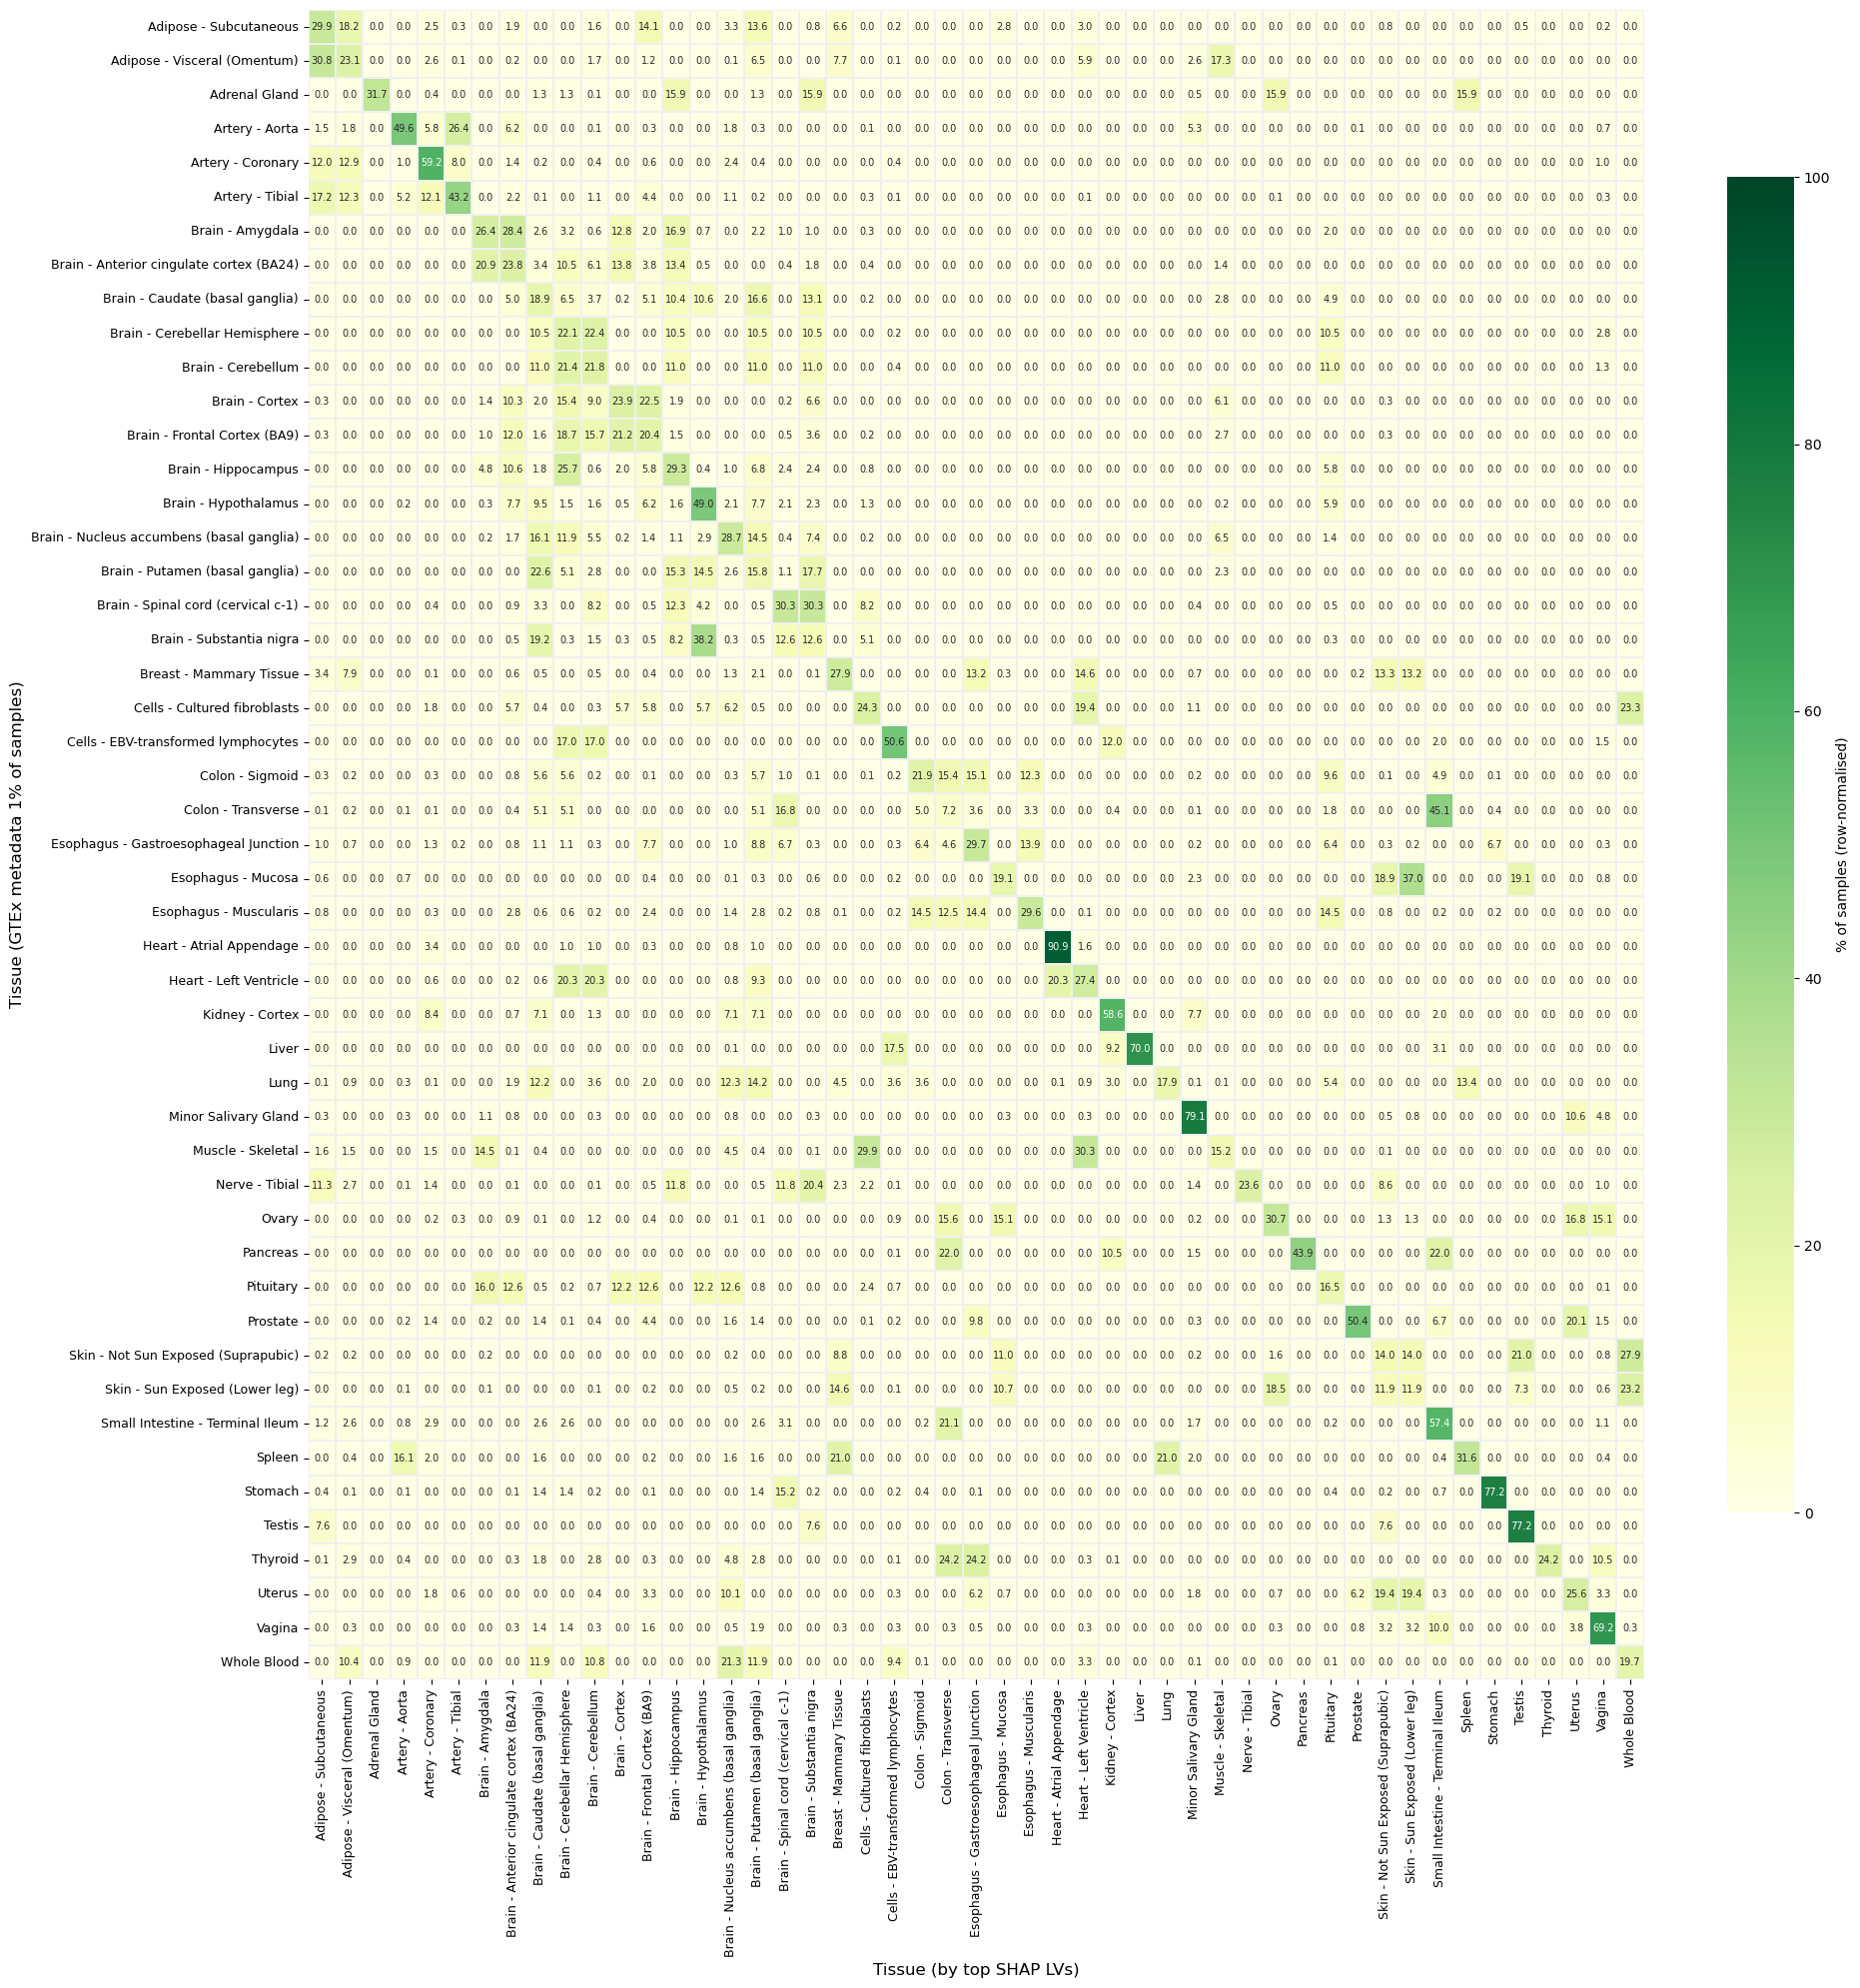

In [21]:
TOP_PCT = 0.01

n_top = max(1, int(len(lv_matrix) * TOP_PCT))
heatmap_matrix = np.zeros((len(tissues_ordered), len(tissues_ordered)))

for j, col_tissue in enumerate(tissues_ordered):
    top_lvs = top_per_tissue.get(col_tissue, [])
    pooled_tissues = []
    for lv in top_lvs:
        top_idx = lv_matrix[lv].nlargest(n_top).index
        pooled_tissues.extend(tissue_labels.loc[top_idx].tolist())
    tissue_counts = pd.Series(pooled_tissues).value_counts()
    for i, row_tissue in enumerate(tissues_ordered):
        heatmap_matrix[i, j] = tissue_counts.get(row_tissue, 0)

row_sums = heatmap_matrix.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
heatmap_matrix_norm = heatmap_matrix / row_sums * 100

heatmap_df = pd.DataFrame(heatmap_matrix_norm, index=tissues_ordered, columns=tissues_ordered)

fig, ax = plt.subplots(figsize=(20, 20))
sns.heatmap(
    heatmap_df,
    cmap='YlGn',
    vmin=0, vmax=100,
    linewidths=0.3,
    linecolor='#f0f0f0',
    ax=ax,
    annot=True,
    fmt='.1f',
    annot_kws={'size': 7},
    cbar_kws={'label': '% of samples (row-normalised)', 'shrink': 0.8}
)
ax.set_xlabel('Tissue (by top SHAP LVs)', fontsize=12)
ax.set_ylabel('Tissue (GTEx metadata 1% of samples)', fontsize=12)
plt.xticks(rotation=90, fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

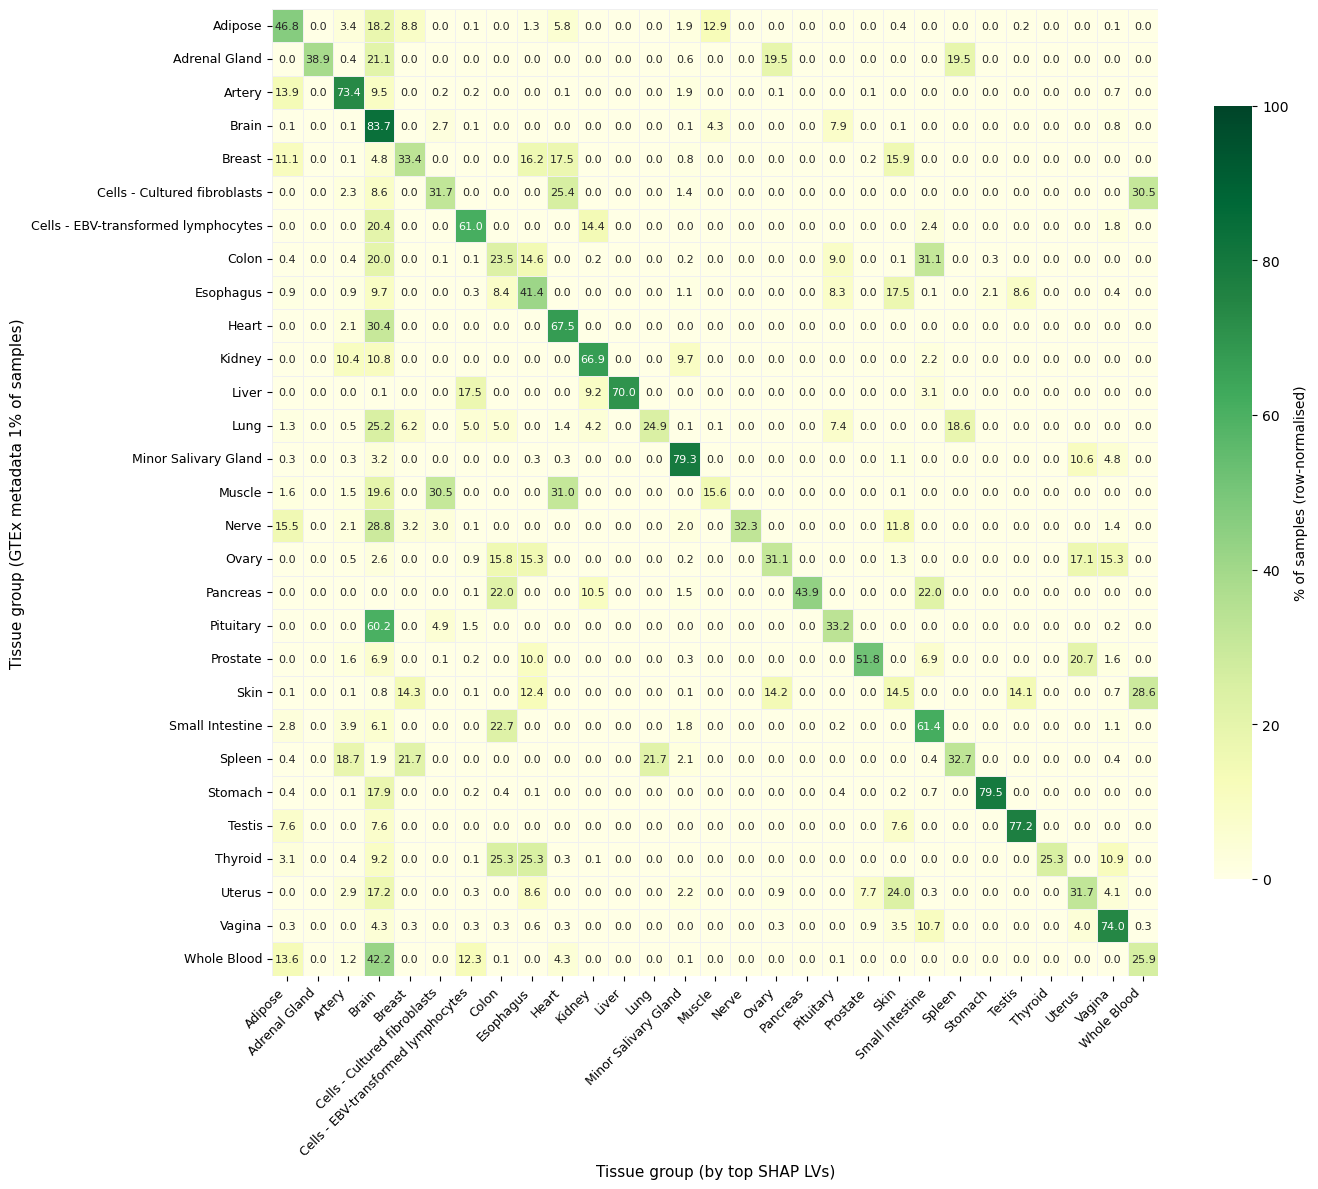

In [14]:
# Grouped heatmap (Cells - kept individual, all others merged by category)
def get_heatmap_group(name):
    if name.startswith('Cells - '):
        return name          # keep Cells subtypes separate
    return name.split(' - ')[0].strip() if ' - ' in name else name


hm_groups = sorted(set(get_heatmap_group(t) for t in tissues_ordered))

# Pool top LVs per group
group_top_lvs_hm = {}
for grp in hm_groups:
    seen_lv = set()
    lvs = []
    for tissue in tissues_ordered:
        if get_heatmap_group(tissue) == grp:
            for lv in top_per_tissue.get(tissue, []):
                if lv not in seen_lv:
                    seen_lv.add(lv)
                    lvs.append(lv)
    group_top_lvs_hm[grp] = lvs

n_grp = len(hm_groups)
hm_grp = np.zeros((n_grp, n_grp))

for j, col_grp in enumerate(hm_groups):
    pooled = []
    for lv in group_top_lvs_hm.get(col_grp, []):
        top_idx = lv_matrix[lv].nlargest(n_top).index
        pooled.extend(tissue_labels.loc[top_idx].tolist())
    if not pooled:
        continue
    grp_counts = pd.Series([get_heatmap_group(t) for t in pooled]).value_counts()
    total = len(pooled)
    for i, row_grp in enumerate(hm_groups):
        hm_grp[i, j] = grp_counts.get(row_grp, 0)

row_sums = hm_grp.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
hm_grp_norm = hm_grp / row_sums * 100
hm_grp_df = pd.DataFrame(hm_grp_norm, index=hm_groups, columns=hm_groups)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    hm_grp_df,
    cmap='YlGn', vmin=0, vmax=100,
    linewidths=0.4, linecolor='#f0f0f0',
    ax=ax, annot=True, fmt='.1f',
    annot_kws={'size': 8},
    cbar_kws={'label': '% of samples (row-normalised)', 'shrink': 0.8}
)
ax.set_xlabel('Tissue group (by top SHAP LVs)', fontsize=11)
ax.set_ylabel('Tissue group (GTEx metadata 1% of samples)', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()
